In [1]:
import matplotlib.pyplot as plt

In [31]:
# Testing objective function output

import desc.io
from desc.objectives import (
    TrappedResonance
)
import numpy as np
from desc.examples import get


## Inputs
eq = desc.io.load("IslandWidthTesting/precise_QA_output.h5")[-1]
# eq = get('HELIOTRON')

# rhos = np.sqrt(np.linspace(0.1,0.9,20)) # rho = sqrt(s)
rhos = np.linspace(0.7**0.5,0.9**0.5,10)
alphas = np.linspace(0,2*np.pi,30)
# pitch_invs = None
N=0
num_transit = 8
wd_blur = 1.2
num_pitch = 2
pitch_invs = np.linspace(1.0795576913196268,1.09,num_pitch)
KE_frac = 1e-5
pp = 0
qq = 1
##

In [32]:
obj = TrappedResonance(
                        eq,
                        rho=rhos,
                        alpha=alphas,
                        N=N, # helicity integer
                        n_max=2,
                        num_transit=num_transit,
                        wd_blur=wd_blur,
                        num_pitch=num_pitch,
                        pitch_method=2,
                        KE_frac=np.array([KE_frac]),
                        pitch_invs=pitch_invs,
                        STAB_SACRIFICE=False, # True = sacrifice Omega_eta' for numerical stability,
                        DEBUG=True,
                        bt_filter_flag=False,
                        rt_filter_flag=False,
                        QS_flag=True,
                        knots_per_transit=100, 
                        num_quad=48
                      )
obj.build()
value = obj.compute(eq.params_dict)

Precomputing transforms


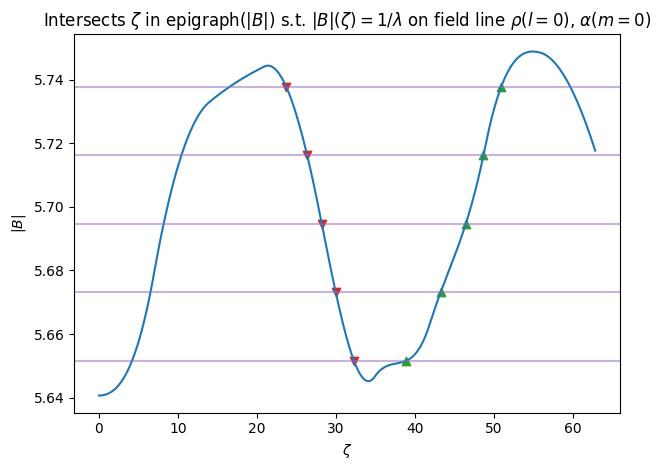

In [15]:
# Plot field line
from desc.integrals.bounce_integral import Bounce1D

num_transit = 10
from desc.examples import get

# eq = get('HELIOTRON')

eq_periodicity = (np.inf,np.inf,np.inf) # periodicity in zeta for these equilibrium to make rtz grid
grid = eq._get_rtz_grid( # returns rho, theta, zeta coordinate grid
    rhos, # radial
    np.array([0]), # poloidal (alpha in this case)
    np.linspace(0,2*np.pi*num_transit,10), # toroidal (zeta in this case)
    coordinates="raz", # rho, alpha, zeta input coordinates
    period=eq_periodicity, # periodicity of coordinate (rho,alpha,zeta)
)

data = eq.compute(
    Bounce1D.required_names + ["min_tz |B|", "max_tz |B|", "g_zz"], grid=grid
)
# Make the bounce integration operator.
bounce1 = Bounce1D(grid.source_grid, data, check=True)
pitch_inv, _ = bounce1.get_pitch_inv_quad(
    min_B=grid.compress(data["min_tz |B|"]),
    max_B=grid.compress(data["max_tz |B|"]),
    num_pitch=5, # currently pitch is manually set in this function
)
l=0
m=0
fig, ax = bounce1.plot(l, m, pitch_inv[l], include_legend=False, show=True) # field line plot

In [16]:
# Average ignoring zero values
from desc.utils import safediv
def npmean_nz(x,axis=0):
    mask = x!=0.0
    count = np.sum(mask,axis) # how many wells that are not 0
    return safediv(np.sum(x,axis=axis) , count)
    # return np.sum(x,axis=axis) / count

In [18]:
# Resonance array information
res_arr = value['res_arr']
print(res_arr)
i_res = 0

[ 0.          1.         -1.          0.5        -0.5         2.
 -2.          3.         -3.          1.5        -1.5         4.
 -4.          2.5        -2.5         3.5        -3.5         3.14159265
  3.14159265  3.14159265  3.14159265  3.14159265  3.14159265  3.14159265
  3.14159265  3.14159265  3.14159265  3.14159265  3.14159265  3.14159265
  3.14159265  3.14159265  3.14159265  3.14159265  3.14159265  3.14159265
  3.14159265  3.14159265  3.14159265  3.14159265  3.14159265]


[-0.01229176 -0.0078242  -0.00393281 -0.00049238  0.00256062  0.00528504
  0.00772742  0.00992541  0.01190987  0.01370646]


Text(0, 0.5, '$d\\Omega_\\eta/d\\rho$')

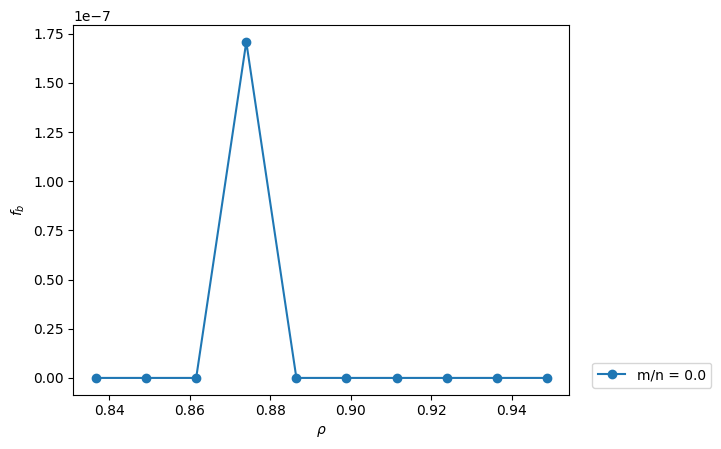

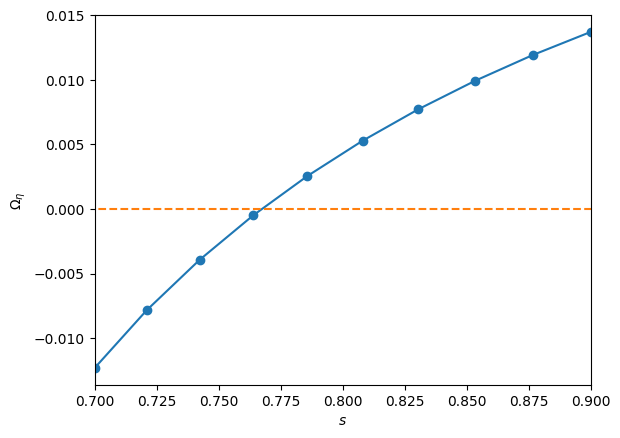

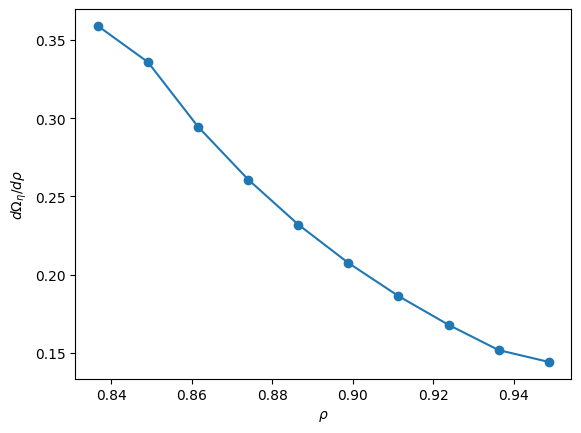

In [37]:
# 1. Is f_b doing what we want it to do?

wd = value['wd']
omega_arr = value['omega_arr'] # := (rho,Bc,well)
# omega_arr = npmean_nz(omega_arr,axis=-1) # := (rho,Bc)
# omega_arr = omega_arr[:,0] # := (rho)
omega_arr = omega_arr[:,0,0] # := (rho)

rhos = value['rhos'] # := (rho)
# rhos = npmean_nz(rhos,axis=-1) # := (rho)

f_b = value['f_b'] # := (rho,Bc,well,res)
# f_b = npmean_nz(f_b,axis=-2) # := (rho,Bc,res)
# f_b = f_b[:,0,:] # := (rho,res)
f_b = f_b[:,0,0,:] # := (rho,res)

res_arr = value['res_arr'] # := (res)

fig1,ax1 = plt.subplots()
for i in range(0,f_b.shape[-1]):
    # if res_arr[i] != np.pi or res_arr[i] == 0 or res_arr[i] == 1:
    if i == i_res:
        ax1.plot(rhos,f_b[:,i],'-o',label='m/n = '+str(res_arr[i]))

# ax1.set_xlabel(r'$\Omega_\eta$')
ax1.set_xlabel(r'$\rho$')
ax1.set_ylabel(r'$f_b$')
ax1.legend(loc='lower right',bbox_to_anchor=(1.3, 0))

fig,ax = plt.subplots()
ax.plot(rhos**2,omega_arr,'-o')
ax.set_xlabel(r'$s$')
ax.set_ylabel(r'$\Omega_\eta$')
ax.plot([0,1],[res_arr[i_res],res_arr[i_res]],'--')
# ax.plot([0,1],[1,1],'--')
# ax.set_ylim([-0.1,0.1])
ax.set_xlim([0.700,0.900])
print(omega_arr)

omega_prime = value['Omega_prime'] # := (rho,Bc,well)
omega_prime = omega_prime[:,0,0,i_res] # := (rho)

fig11,ax11 = plt.subplots()
ax11.plot(rhos,omega_prime,'-o')
ax11.set_xlabel(r'$\rho$')
ax11.set_ylabel(r'$d\Omega_\eta/d\rho$')

s_John =  0.7638779525863899
Delta_s_John =  0.07694632237244192


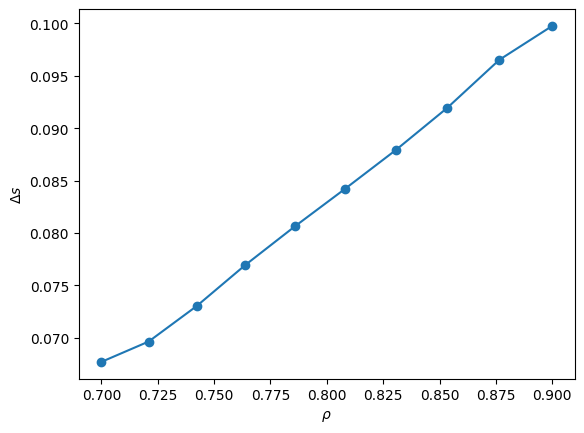

In [47]:
# 2. Is the island width correct?
'''
Delta psi = 4^4 (  ( int_0^{2*pi}psi_drift^2 ) / (Omega_eta^2 pi n^2) )  ^(1/4)
rho = sqrt(psi/psi_a)
See Overleaf for complete derivation
'''

import numpy as np

Delta_s_4 = value['Delta_s_4'] # := (rho,Bcrit,well,res)
Delta_s = 4 * (( (1/np.pi) * (1/value['Omega_prime']) * value['Delta_s_4'] )**(1/4)) # := (rho,Bcrit,well,res)

fig9,ax9 = plt.subplots()
ax9.plot(rhos**2,Delta_s[:,0,0,i_res],'-o')
ax9.set_xlabel(r'$\rho$')
ax9.set_ylabel(r'$\Delta s$')

print('s_John = ',(rhos**2)[3])
print('Delta_s_John = ',Delta_s[3,0,0,i_res]) # this is the conservative estimate, try non-conservative



Text(0, 0.5, '$\\Omega_\\eta$')

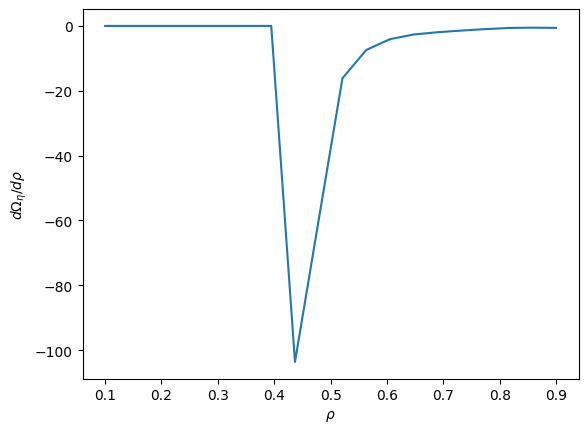

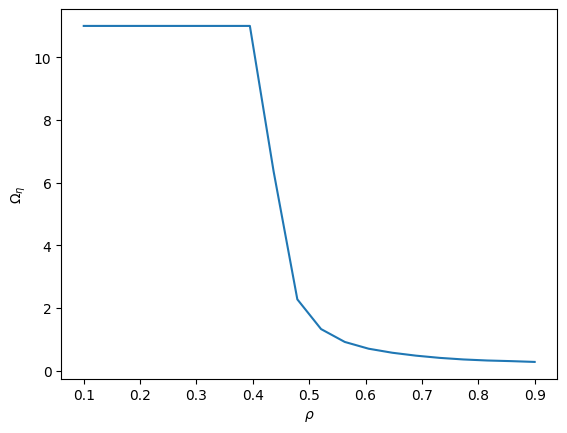

In [6]:
# Testing

# Omega_prime - this looks fine
fig3,ax3 = plt.subplots()
ax3.plot(rhos,value['Omega_prime'][:,0,0,i_res])
ax3.set_xlabel(r'$\rho$')
ax3.set_ylabel(r'$d\Omega_\eta/d\rho$')

fig3,ax3 = plt.subplots()
ax3.plot(rhos,value['omega_arr'][:,0,0])
ax3.set_xlabel(r'$\rho$')
ax3.set_ylabel(r'$\Omega_\eta$')

0.6708203932499369


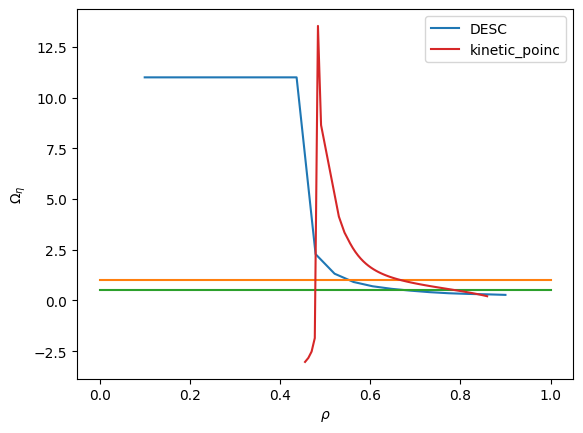

In [13]:
print(np.sqrt(0.45))
fig5,ax5 = plt.subplots()
ax5.plot(value['rhos'],value['omega_arr'][:,0,0],label='DESC')
ax5.set_xlabel(r'$\rho$')
ax5.set_ylabel(r'$\Omega_\eta$')
ax5.plot([0,1],[1,1])
ax5.plot([0,1],[0.5,0.5])

s_kpoinc = np.loadtxt('rad_perfect.txt')
omega_eta_kpoinc = np.loadtxt('omega_perfect.txt')
ax5.plot(s_kpoinc**0.5,-omega_eta_kpoinc,label='kinetic_poinc')
ax5.legend()
# ax5.set_ylim([0,2])

Text(0.5, 1.0, '$B_{crit} = 5.999$ T')

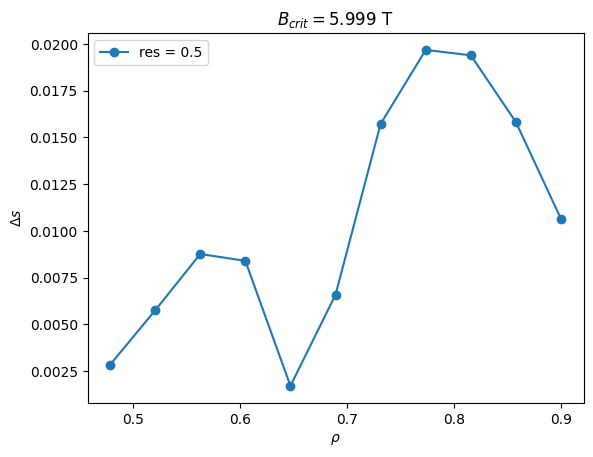

In [25]:
fig2,ax2 = plt.subplots()
ax2.plot(rhos,Deltapsi[:,0,i_res],'-o',label='res = '+ str(value['res_arr'][i_res]))
ax2.legend()
ax2.set_xlabel(r'$\rho$')
ax2.set_ylabel(r'$\Delta s$')
ax2.set_title(r'$B_{crit} = 5.999$ T')

In [ ]:
# 3. Does increasing resolution of rho, alpha, Bcrit individually cause the objective function to asymptote to a single value?

val_list = []
resol_list = []

import numpy as np

import desc.io
from desc.objectives import (
    TrappedResonance
)
import numpy as np
from desc.examples import get


## Inputs
eq = get('HELIOTRON')
# eq = desc.io.load("equil_G1600_DESC_fixed.h5")

num_loop = 15

# num_pitch = np.linspace(4,128,num_loop)
num_pitch = np.ones(num_loop) * 16
j=0
for i in np.linspace(1,15,num_loop):
    # rhos = np.linspace(0.1,0.9,int(20*i))
    rhos = np.linspace(0.1,0.9,50)
    alphas = np.linspace(0,2*np.pi,int(3*i))
    # alphas = np.linspace(0,2*np.pi,3)
    N=0
    num_transit = 6
    wd_blur = 1.2

    obj = TrappedResonance(
                        eq,
                        rho=rhos,
                        alpha=alphas,
                        N=N, # helicity integer
                        n_max=1,
                        num_transit=num_transit,
                        wd_blur=wd_blur,
                        num_pitch=int(num_pitch[j]),
                        pitch_method=1,
                        # pitch_invs=pitch_invs,
                        STAB_SACRIFICE=True, # True = sacrifice Omega_eta' for numerical stability
                        DEBUG=False
                      )
    obj.build()
    val_list.append(obj.compute(eq.params_dict))
    resol_list.append(len(rhos))
    
    j+=1


Precomputing transforms
Precomputing transforms


Text(0, 0.5, 'Value of $f$')

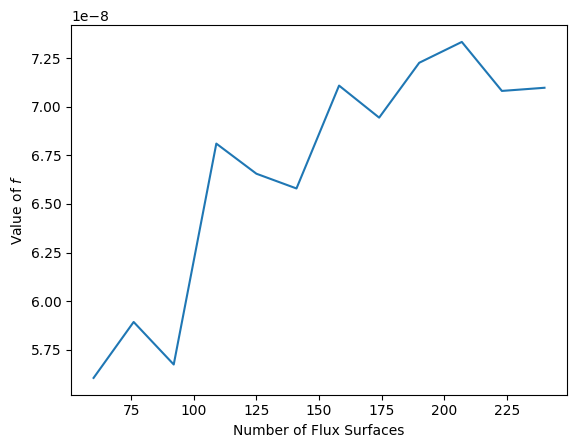

In [8]:
fig3,ax3 = plt.subplots()
ax3.plot(resol_list,val_list)
ax3.set_xlabel("Number of Flux Surfaces")
ax3.set_ylabel(r'Value of $f$')

In [16]:
eq = desc.io.load('desc_eq_beta2.5_QA.h5')
rho_iota = np.linspace(0.01,0.99,30)
eq_periodicity = (np.inf,np.inf,np.inf) # periodicity in zeta for these equilibrium to make rtz grid
grid = eq._get_rtz_grid( # returns rho, theta, zeta coordinate grid
    rho_iota, # radial
    np.array([0]), # poloidal (alpha in this case)
    np.array([0]), # toroidal (zeta in this case)
    coordinates="raz", # rho, alpha, zeta input coordinates
    period=eq_periodicity, # periodicity of coordinate (rho,alpha,zeta)
)
eqiota = eq.compute('iota',grid=grid)['iota']


In [17]:
eq_nfp = eq.NFP
B0 = eq.compute('<|B|>_axis',grid=grid)['<|B|>_axis']
Psi = eq.compute('Psi')['Psi'][-1]

In [18]:
print(eq_nfp)
print(B0)
print(eqiota[0])
print(Psi)

2
5.692717303105414
-0.15129421757056347
51.35115868353138
